In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as trasforms
import matplotlib.pyplot as plt

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
input_size=784
hidden_size=100
num_classes=10
epochs=2
batch_size=100
learning_rate=0.001

In [5]:
train_dataset=torchvision.datasets.MNIST(root='./data',train=True,transform=trasforms.ToTensor(),download=True)

100%|██████████| 9.91M/9.91M [00:54<00:00, 182kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 70.7kB/s]
100%|██████████| 1.65M/1.65M [00:10<00:00, 151kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.28MB/s]


In [ ]:
test_dataset=torchvision.datasets.MNIST(root='./data',train=False,transform=trasforms.ToTensor(),download=False)

In [8]:
train_loader=torch.utils.data.DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True)
test_loader=torch.utils.data.DataLoader(dataset=test_dataset,batch_size=batch_size,shuffle=True)

In [11]:
examples=iter(train_loader)
samples,labels=next(examples)

print(samples.shape,labels.shape)

torch.Size([100, 1, 28, 28]) torch.Size([100])


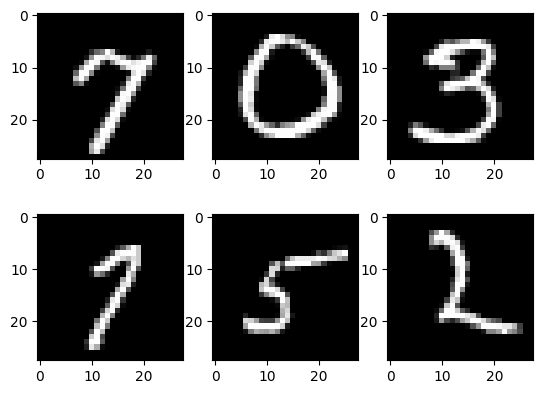

In [12]:
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(samples[i][0],cmap='gray')
plt.show()

In [20]:
class Neuralnet(nn.Module):
    def __init__(self,input_size,hidden_size,num_classes):
        super(Neuralnet,self).__init__()
        self.l1=nn.Linear(input_size,hidden_size)
        self.relu=nn.ReLU()
        self.l2=nn.Linear(hidden_size,num_classes)
    
    def forward(self,X):
        out=self.l1(X)
        out=self.relu(out)
        out=self.l2(out)
        return out

In [21]:
model=Neuralnet(input_size=input_size,hidden_size=hidden_size,num_classes=num_classes)


In [22]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [23]:
n_total_steps=len(train_loader)

for epoch in range(epochs):
    for i,(images,labels) in enumerate(train_loader):
        images=images.reshape(-1,28*28).to(device)
        labels=labels.to(device)

        outputs=model(images)
        loss=criterion(outputs,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1)%100==0:
            print(f'epoch {epoch+1}/{epochs}, steps{i+1}/{epochs},loss={loss}')


epoch 1/2, steps100/2,loss=0.4219276010990143
epoch 1/2, steps200/2,loss=0.2103249877691269
epoch 1/2, steps300/2,loss=0.38066256046295166
epoch 1/2, steps400/2,loss=0.14650367200374603
epoch 1/2, steps500/2,loss=0.1024409681558609
epoch 1/2, steps600/2,loss=0.20838239789009094
epoch 2/2, steps100/2,loss=0.26746928691864014
epoch 2/2, steps200/2,loss=0.15058553218841553
epoch 2/2, steps300/2,loss=0.15363751351833344
epoch 2/2, steps400/2,loss=0.2001761943101883
epoch 2/2, steps500/2,loss=0.19635681807994843
epoch 2/2, steps600/2,loss=0.14641273021697998


In [25]:
with torch.no_grad():
    n_correct=0
    n_samples=0

    for images,labels in test_loader:

        images=images.reshape(-1,28*28).to(device)
        labels=labels.to(device)

        outputs=model(images)

        _,predictions=torch.max(outputs,1)
        n_samples+=labels.shape[0]
        n_correct+=(predictions==labels).sum().item()
    
    acc=100*n_correct/n_samples

    print("accuracy=",acc)

accuracy= 95.76333333333334
